In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("/content/Students suspicious behaviors detection dataset_V1.csv")

In [3]:
le = LabelEncoder()
df['head_pose']      = le.fit_transform(df['head_pose'].astype(str))
df['gaze_direction'] = le.fit_transform(df['gaze_direction'].astype(str))

In [4]:
df.fillna(df.median(numeric_only=True), inplace=True)

In [5]:
X = df.drop('label', axis=1)
y = df['label']

In [6]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test  = scaler.transform(X_test)

In [8]:
param_grid = {'n_neighbors': list(range(1, 21))}
grid = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train, y_train)

best_k  = grid.best_params_['n_neighbors']
best_cv = grid.best_score_
print(f"Best K     : {best_k}")
print(f"CV Accuracy: {best_cv*100:.2f}%")

Best K     : 1
CV Accuracy: 98.86%


In [9]:
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)
y_pred = knn.predict(X_test)

print(f"Test Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Normal (0)', 'Suspicious (1)']))

Test Accuracy: 98.64%

Classification Report:
                precision    recall  f1-score   support

    Normal (0)       0.98      0.99      0.99       569
Suspicious (1)       0.99      0.98      0.99       531

      accuracy                           0.99      1100
     macro avg       0.99      0.99      0.99      1100
  weighted avg       0.99      0.99      0.99      1100



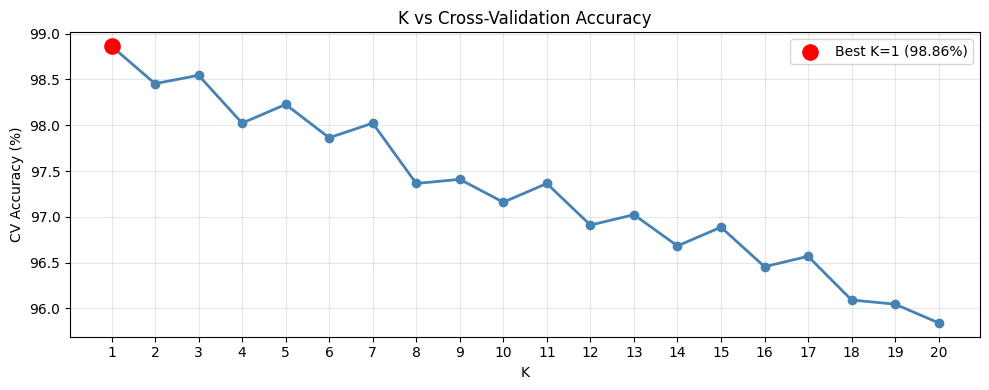

In [10]:
plt.figure(figsize=(10, 4))
k_scores = grid.cv_results_['mean_test_score']
plt.plot(range(1, 21), k_scores * 100, 'o-', color='steelblue', linewidth=2)
plt.scatter([best_k], [best_cv * 100], color='red', s=120, zorder=5,
            label=f'Best K={best_k} ({best_cv*100:.2f}%)')
plt.xlabel('K')
plt.ylabel('CV Accuracy (%)')
plt.title('K vs Cross-Validation Accuracy')
plt.xticks(range(1, 21))
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

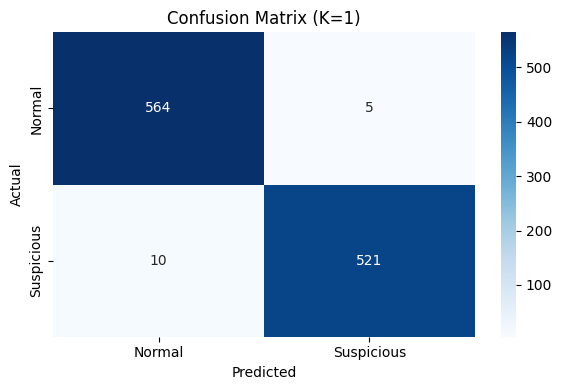

In [11]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues',
            xticklabels=['Normal', 'Suspicious'],
            yticklabels=['Normal', 'Suspicious'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix (K={best_k})')
plt.tight_layout()
plt.show()